In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('Financial_Inclusion_Dataset.xlsx')
display(df.head())

,Rank,State / Union Territory,Number of Bank Branches,Credit-Deposit Ratio (%),Total Deposits (Rs. Crore),Access Score (0-100),Usage Score (0-100),Inclusion Gap (Access minus Usage),TFII Score (0-100),Inclusion Category
0,1,Maharashtra,14832,98.1,5233966,88.15,98.1,-9.95,94.12,High Inclusion
1,2,Tamil Nadu,13204,115.4,1463026,47.92,100.0,-52.08,79.17,High Inclusion
2,3,Andhra Pradesh,8087,151.1,529673,25.83,100.0,-74.17,70.33,High Inclusion
3,4,Telangana,6269,111.6,867571,24.38,100.0,-75.62,69.75,High Inclusion
4,5,Delhi,3981,91.8,2071013,29.98,91.8,-61.82,67.07,High Inclusion


In [6]:
df['TFII Score (0-100)'].describe()

,TFII Score (0-100)
count,36.000000
mean,43.624167
std,19.204555
min,7.620000
25%,27.947500
50%,42.710000
75%,57.750000
max,94.120000


<Axes: xlabel='TFII Score (0-100)', ylabel='Count'>

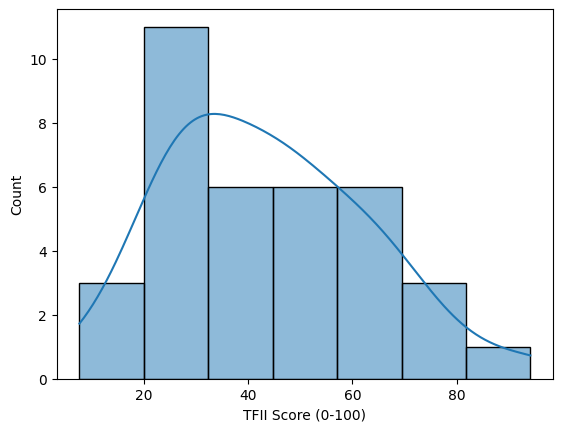

In [7]:
import seaborn as sns
sns.histplot(df['TFII Score (0-100)'], kde=True)

In [9]:
df['TFII Score (0-100)'].skew()


np.float64(0.5330026271412839)

<Axes: xlabel='Number of Bank Branches', ylabel='Count'>

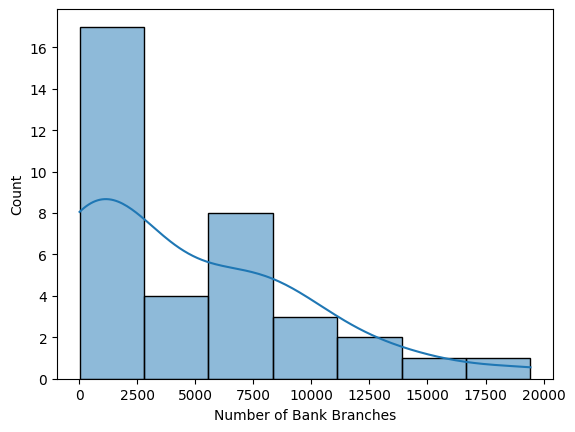

In [20]:
sns.histplot(df['Number of Bank Branches'], kde=True)

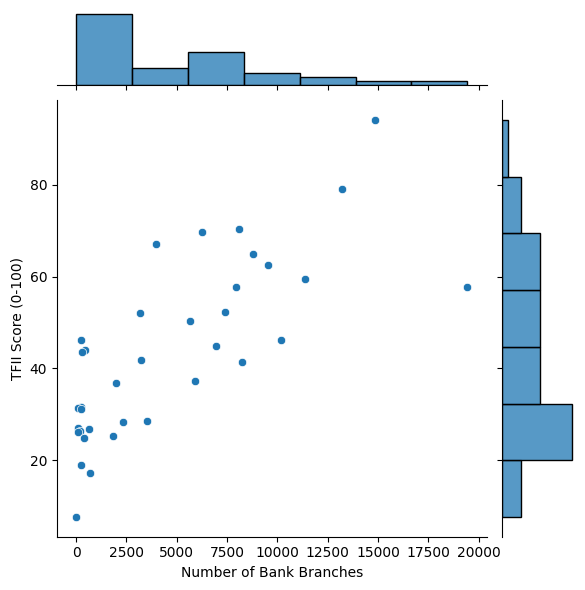

In [13]:
sns.jointplot(x='Number of Bank Branches', y='TFII Score (0-100)', data=df)

In [15]:
df['Number of Bank Branches'].skew()

np.float64(1.1113039389093904)

<Axes: xlabel='Credit-Deposit Ratio (%)', ylabel='Count'>

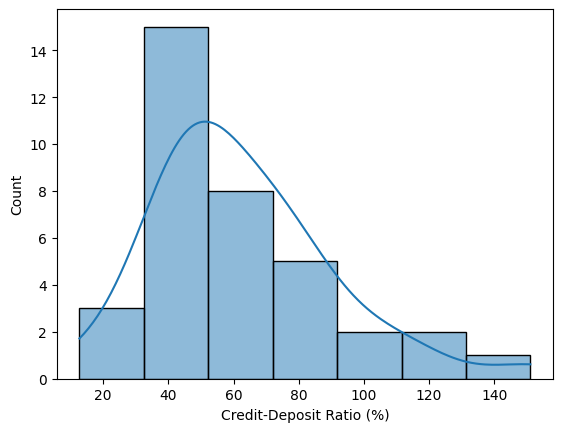

In [25]:
sns.histplot(df['Credit-Deposit Ratio (%)'], kde=True)

In [26]:
 df['Credit-Deposit Ratio (%)'].skew()

np.float64(1.113072773605774)

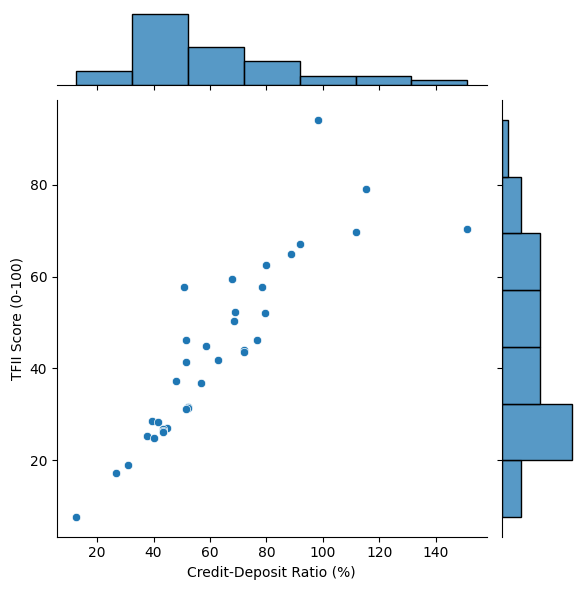

In [27]:
sns.jointplot(x='Credit-Deposit Ratio (%)', y='TFII Score (0-100)', data=df)

<Axes: xlabel='Total Deposits (Rs. Crore)', ylabel='Count'>

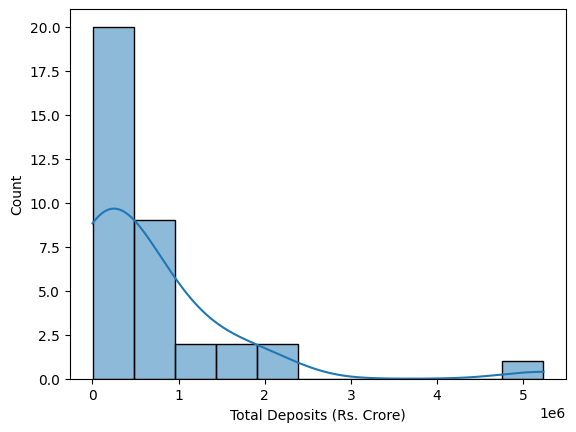

In [30]:
sns.histplot(df['Total Deposits (Rs. Crore)'], kde=True)

In [31]:
 df['Total Deposits (Rs. Crore)'].skew()

np.float64(3.1609598824245433)

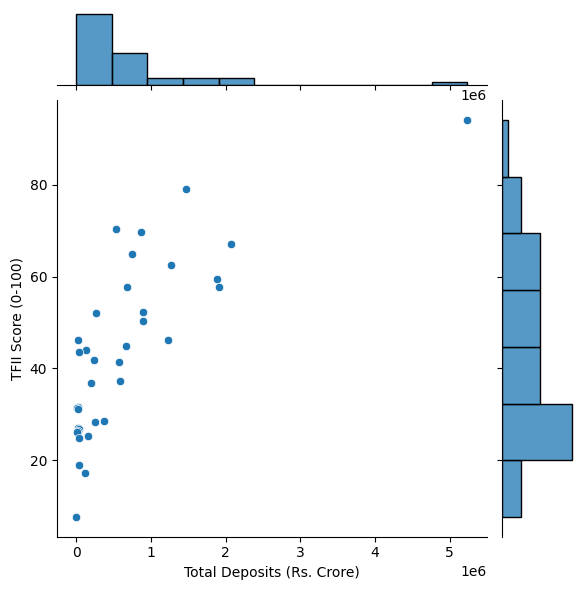

In [32]:
sns.jointplot(x='Total Deposits (Rs. Crore)', y='TFII Score (0-100)', data=df)

In [33]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [35]:
model1 = ols('Q("TFII Score (0-100)") ~ Q("Number of Bank Branches")', data=df).fit()

In [38]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("TFII Score (0-100)")   R-squared:                       0.580
Model:                                 OLS   Adj. R-squared:                  0.567
Method:                      Least Squares   F-statistic:                     46.89
Date:                     Wed, 22 Apr 2026   Prob (F-statistic):           6.98e-08
Time:                             08:30:44   Log-Likelihood:                -141.36
No. Observations:                       36   AIC:                             286.7
Df Residuals:                           34   BIC:                             289.9
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       29.8714      2.910     10.266      0.000      23.958      35.785
Q("Number of Bank Branches")     0.0030      0.000      6.848      0.000       0.002       0.004
==============================================================================
Omnibus:                        0.001   Durbin-Watson:                   0.884
Prob(Omnibus):                  0.999   Jarque-Bera (JB):                0.134
Skew:                           0.011   Prob(JB):                        0.935
Kurtosis:                       2.702   Cond. No.                     9.33e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.33e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
predictions = model1.predict(df)
actual = df['TFII Score (0-100)']
residuals = actual - predictions
mse = (residuals**2).mean()
rmse = np.sqrt(mse)
print(f"RMSE for model1: {rmse}")

RMSE for model1: 12.276476666270597


In [41]:
model2 = ols('Q("TFII Score (0-100)") ~ Q("Credit-Deposit Ratio (%)") + Q("Number of Bank Branches")', data=df).fit()

In [42]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("TFII Score (0-100)")   R-squared:                       0.923
Model:                                 OLS   Adj. R-squared:                  0.918
Method:                      Least Squares   F-statistic:                     198.1
Date:                     Wed, 22 Apr 2026   Prob (F-statistic):           4.12e-19
Time:                             08:40:19   Log-Likelihood:                -110.78
No. Observations:                       36   AIC:                             227.6
Df Residuals:                           33   BIC:                             232.3
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         6.3603      2.312      2.751      0.010       1.657      11.064
Q("Credit-Deposit Ratio (%)")     0.4651      0.038     12.143      0.000       0.387       0.543
Q("Number of Bank Branches")      0.0017      0.000      8.161      0.000       0.001       0.002
==============================================================================
Omnibus:                       16.636   Durbin-Watson:                   1.537
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.214
Skew:                          -0.536   Prob(JB):                     4.19e-15
Kurtosis:                       9.557   Cond. No.                     1.71e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.71e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
predictions_model2 = model2.predict(df)
actual_model2 = df['TFII Score (0-100)']
residuals_model2 = actual_model2 - predictions_model2
mse_model2 = (residuals_model2**2).mean()
rmse_model2 = np.sqrt(mse_model2)
print(f"RMSE for model2: {rmse_model2}")

RMSE for model2: 5.250053630325577


In [45]:
model3 = ols('Q("TFII Score (0-100)") ~ Q("Credit-Deposit Ratio (%)") + Q("Number of Bank Branches") + Q("Total Deposits (Rs. Crore)")', data=df).fit()

In [46]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Q("TFII Score (0-100)")   R-squared:                       0.966
Model:                                 OLS   Adj. R-squared:                  0.963
Method:                      Least Squares   F-statistic:                     301.2
Date:                     Wed, 22 Apr 2026   Prob (F-statistic):           1.59e-23
Time:                             08:42:07   Log-Likelihood:                -96.202
No. Observations:                       36   AIC:                             200.4
Df Residuals:                           32   BIC:                             206.7
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           7.7063      1.580      4.876      0.000       4.487      10.925
Q("Credit-Deposit Ratio (%)")       0.4447      0.026     17.008      0.000       0.391       0.498
Q("Number of Bank Branches")        0.0009      0.000      4.251      0.000       0.000       0.001
Q("Total Deposits (Rs. Crore)")  6.202e-06   9.82e-07      6.318      0.000     4.2e-06     8.2e-06
==============================================================================
Omnibus:                       30.398   Durbin-Watson:                   1.408
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.997
Skew:                          -1.882   Prob(JB):                     5.76e-19
Kurtosis:                       9.468   Cond. No.                     2.99e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.99e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [47]:
predictions_model3 = model3.predict(df)
actual_model3 = df['TFII Score (0-100)']
residuals_model3 = actual_model3 - predictions_model3
mse_model3 = (residuals_model3**2).mean()
rmse_model3 = np.sqrt(mse_model3)
print(f"RMSE for model3: {rmse_model3}")

RMSE for model3: 3.502013907505981


In [48]:
rmse_data = {
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'RMSE': [rmse, rmse_model2, rmse_model3]
}
rmse_df = pd.DataFrame(rmse_data)
print(rmse_df.to_markdown(index=False))

| Model   |     RMSE |
|:--------|---------:|
| Model 1 | 12.2765  |
| Model 2 |  5.25005 |
| Model 3 |  3.50201 |


/tmp/ipykernel_2963/1822808062.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=rmse_df, palette='viridis')


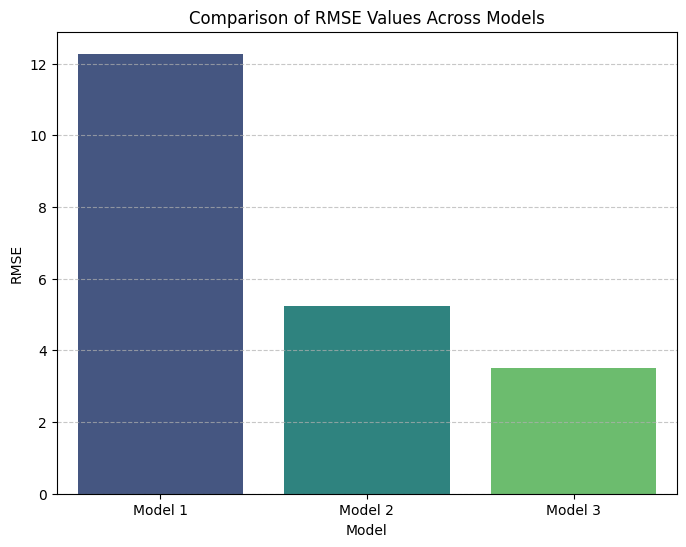

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='RMSE', hue='Model', data=rmse_df, palette='viridis', legend=False)
plt.title('Comparison of RMSE Values Across Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on these RMSE values, Model 3 has the lowest RMSE (3.50), indicating that it is the best-performing model among the three, as it has the smallest average prediction error. Therefore, I recommend choosing Model 3 for predicting the 'TFII Score (0-100)'.

Here's a comparison of the RMSE values for all the models, presented in a table.

Model	RMSE
Model 1	12.28
Model 2	5.25
Model 3	3.50
Based on these RMSE values, Model 3 has the lowest RMSE (3.50), indicating that it is the best-performing model among the three, as it has the smallest average prediction error. Therefore, I recommend choosing Model 3 for predicting the 'TFII Score (0-100)'.